# 🔍 Эксплораторный анализ мастер-датасета SCADA АО «Москоллектор»

**Цель ноутбука**: Провести аудит качества, физической адекватности и баланса мастер-датасета перед обучением моделей:
- `clean_train_stream.parquet` (2020–2024, ~9.1 млн строк)
- `clean_val_stream.parquet` (2025, ~2.0 млн строк)
- `clean_test_stream.parquet` (2026, ~1.07 млн строк)

**Окружение**: Чтение данных выполняется строго через движок **DuckDB** (14 потоков) для обхода аппаратного ограничения процессора Xeon (отсутствие AVX2).

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Инициализация DuckDB с оптимизацией под 14 потоков Xeon
con = duckdb.connect()
con.execute("PRAGMA threads=14;")
con.execute("PRAGMA memory_limit='8GB';")

# Фирменная палитра ЛЦТ 2026
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1C1D22'
plt.rcParams['axes.facecolor'] = '#252730'
plt.rcParams['axes.edgecolor'] = '#3A3D4A'
plt.rcParams['grid.color'] = '#3A3D4A'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['axes.labelcolor'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#FFFFFF'
plt.rcParams['ytick.color'] = '#FFFFFF'

PINK = '#FF0053'
PURPLE = '#8A83D1'
GREEN = '#10B981'
YELLOW = '#F59E0B'

print(" DuckDB успешно сконфигурирован. Стенд готов к исследованию.")

 DuckDB успешно сконфигурирован. Стенд готов к исследованию.


In [3]:
DATA_DIR = "g:/lct2/production_ml/data"  # или где именно они у тебя лежат

# Нормализуем слэши для DuckDB
DATA_DIR = DATA_DIR.replace("\\", "/")

print(f"Ищем файлы в: {DATA_DIR}")

# Проверяем, что файлы на месте
train_path = f"{DATA_DIR}/clean_train_stream.parquet"
val_path   = f"{DATA_DIR}/clean_val_stream.parquet"
test_path  = f"{DATA_DIR}/clean_test_stream.parquet"

print("Train найден:", os.path.exists(train_path))
print("Val найден:", os.path.exists(val_path))
print("Test найден:", os.path.exists(test_path))

Ищем файлы в: g:/lct2/production_ml/data
Train найден: True
Val найден: True
Test найден: True


In [17]:
pd.set_option('display.max_columns', None)
con.execute(f"""
SELECT * FROM '{train_path}'
LIMIT 10
""").df()

,channel_id,obs_time,year,subsystem_type,sensor_type,is_holdout,target,horizon_hours,events_24h,silence_drop_12h,silence_drop_3h,activity_ratio_30d,value_freezing_rate,night_fraction_24h,alarm_ratio_24h,analog_std_24h,analog_drift_12h,hour_of_day,day_of_week,is_weekend,is_heating_season
0,103979,2020-01-01,2020,Диспетчерский контроль,Состояние насоса,False,0,NaN,2.0,0.3333,0.3333,0.2000,0.5,0.6667,0.0,0.0000,0.0,0,3,0,1
1,104032,2020-01-01,2020,Газовая охрана,Газовый датчик,True,0,NaN,40.0,0.0244,0.0244,0.1653,0.5,0.9756,0.0,0.0051,0.0,0,3,0,1
2,104042,2020-01-01,2020,Газовая охрана,Газовый датчик,True,0,NaN,10.0,0.0909,0.0909,0.0163,0.5,0.9091,0.0,0.0053,0.0,0,3,0,1
3,104062,2020-01-01,2020,Газовая охрана,Газовый датчик,True,0,NaN,56.0,0.0175,0.0175,0.1380,0.5,0.9825,0.0,0.0050,0.0,0,3,0,1
4,114014,2020-01-01,2020,Пожарная охрана,Состояние УИР-Р,False,0,NaN,2.0,0.3333,0.3333,0.6000,0.5,0.6667,0.0,0.0000,0.0,0,3,0,1
5,116113,2020-01-01,2020,Газовая охрана,Газовый датчик,False,0,NaN,10.0,0.0909,0.0909,0.0201,0.5,0.9091,0.0,0.0053,0.0,0,3,0,1
6,116117,2020-01-01,2020,Газовая охрана,Газовый датчик,True,0,NaN,4.0,0.2000,0.2000,0.0595,0.5,0.8000,0.0,0.0058,0.0,0,3,0,1
7,116128,2020-01-01,2020,Газовая охрана,Газовый датчик,False,0,NaN,55.0,0.0179,0.0179,0.2276,0.5,0.9821,0.0,0.0050,0.0,0,3,0,1
8,116129,2020-01-01,2020,Газовая охрана,Газовый датчик,False,0,NaN,12.0,0.0769,0.0769,0.1940,0.5,0.9231,0.0,0.0052,0.0,0,3,0,1
9,116131,2020-01-01,2020,Газовая охрана,Газовый датчик,True,0,NaN,22.0,0.0435,0.0435,0.1106,0.5,0.9565,0.0,0.0051,0.0,0,3,0,1


## 1. Сводные метрики объемов и целостности выборок
Проверим общее количество строк, число уникальных датчиков и фактическую базовую долю аварий ($y=1$).

In [5]:
summary_query = f"""
SELECT 
    'Train (2020-2024)' AS split,
    COUNT(*) AS total_rows,
    SUM(target) AS failure_hours,
    ROUND(100.0 * SUM(target) / COUNT(*), 3) AS failure_pct,
    COUNT(DISTINCT channel_id) AS unique_channels
FROM '{train_path}'
UNION ALL
SELECT 
    'Val (2025)' AS split,
    COUNT(*),
    SUM(target),
    ROUND(100.0 * SUM(target) / COUNT(*), 3),
    COUNT(DISTINCT channel_id)
FROM '{val_path}'
UNION ALL
SELECT 
    'Test (2026)' AS split,
    COUNT(*),
    SUM(target),
    ROUND(100.0 * SUM(target) / COUNT(*), 3),
    COUNT(DISTINCT channel_id)
FROM '{test_path}';
"""
summary_df = con.execute(summary_query).df()
display(summary_df)

,split,total_rows,failure_hours,failure_pct,unique_channels
0,Train (2020-2024),9103056,9468.0,0.104,10377
1,Val (2025),1986342,2593.0,0.131,11320
2,Test (2026),1075445,3469.0,0.323,11218


## 2. Распределение инцидентов по подсистемам
Посмотрим, сколько реальных сбоев приходится на каждую инженерную подсистему и какова медианная активность датчиков.

,subsystem_type,total_slices,failures,failure_share_pct,median_events_24h,avg_events_24h
0,Диспетчерский контроль,2097729,7014.0,74.08,4.0,31.3
1,Газовая охрана,4076972,2187.0,23.10,388.0,794.6
2,Охранная подсистема,1614634,90.0,0.95,24.0,200.7
3,Пожарная охрана,727573,87.0,0.92,4.0,97.6
4,Диагностическая подсистема,22703,80.0,0.84,6.0,36.9
5,Температурная подсистема,563445,10.0,0.11,3.0,6.4


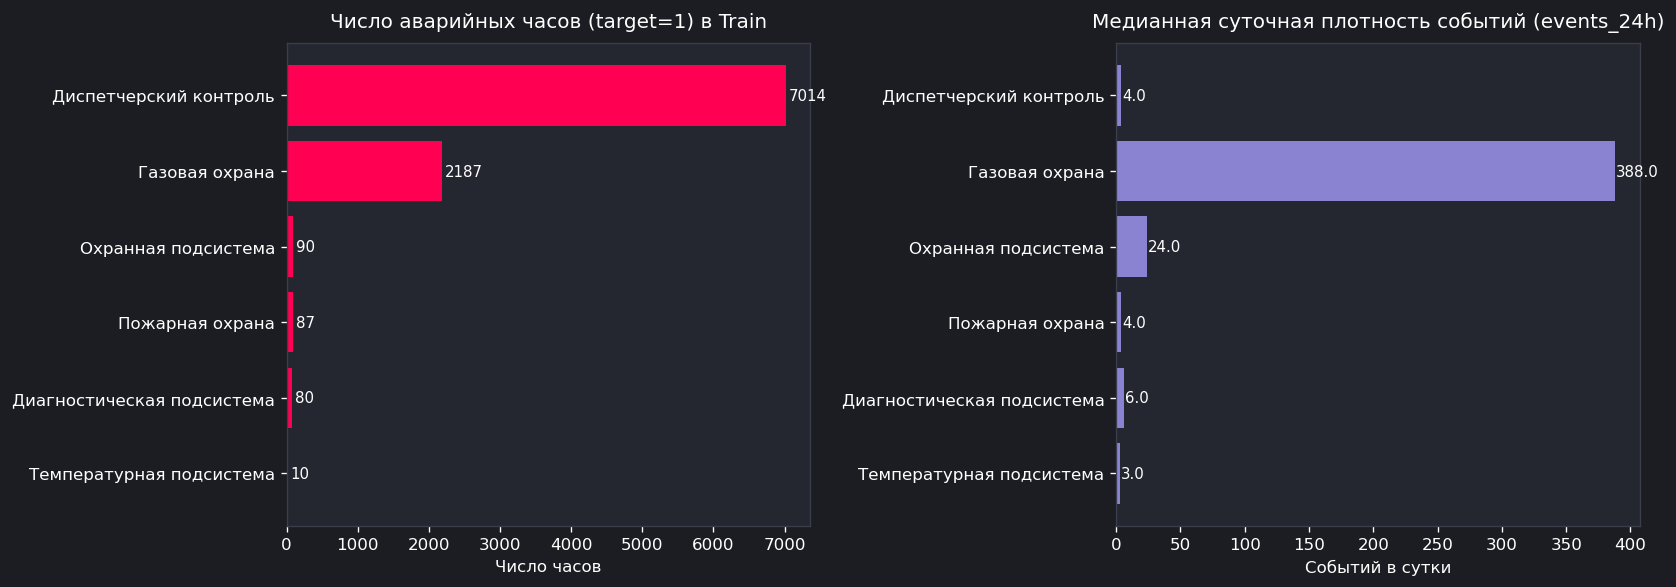

In [6]:
subsys_query = f"""
SELECT 
    subsystem_type,
    COUNT(*) AS total_slices,
    SUM(target) AS failures,
    ROUND(100.0 * SUM(target) / NULLIF(SUM(SUM(target)) OVER (), 0), 2) AS failure_share_pct,
    ROUND(MEDIAN(events_24h), 1) AS median_events_24h,
    ROUND(AVG(events_24h), 1) AS avg_events_24h
FROM '{train_path}'
GROUP BY subsystem_type
ORDER BY failures DESC;
"""
subsys_df = con.execute(subsys_query).df()
display(subsys_df)

# Визуализация распределения аварий
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

bars1 = ax1.barh(subsys_df['subsystem_type'], subsys_df['failures'], color=PINK)
ax1.set_title('Число аварийных часов (target=1) в Train', fontsize=12, pad=10)
ax1.set_xlabel('Число часов')
ax1.invert_yaxis()
for b in bars1:
    ax1.text(b.get_width() + 40, b.get_y() + b.get_height()/2, f'{int(b.get_width())}', va='center', fontsize=9)

bars2 = ax2.barh(subsys_df['subsystem_type'], subsys_df['median_events_24h'], color=PURPLE)
ax2.set_title('Медианная суточная плотность событий (events_24h)', fontsize=12, pad=10)
ax2.set_xlabel('Событий в сутки')
ax2.invert_yaxis()
for b in bars2:
    ax2.text(b.get_width() + 1, b.get_y() + b.get_height()/2, f'{b.get_width():.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Физический конфликт: Аналоговые vs Дискретные датчики
Наглядно сравним плотность телеметрии датчиков метана (`Газовая охрана`) и рубильников/насосов (`Диспетчерский контроль`).
Именно этот разрыв на 2 порядка объясняет, почему единое дерево решений слепло к газу.

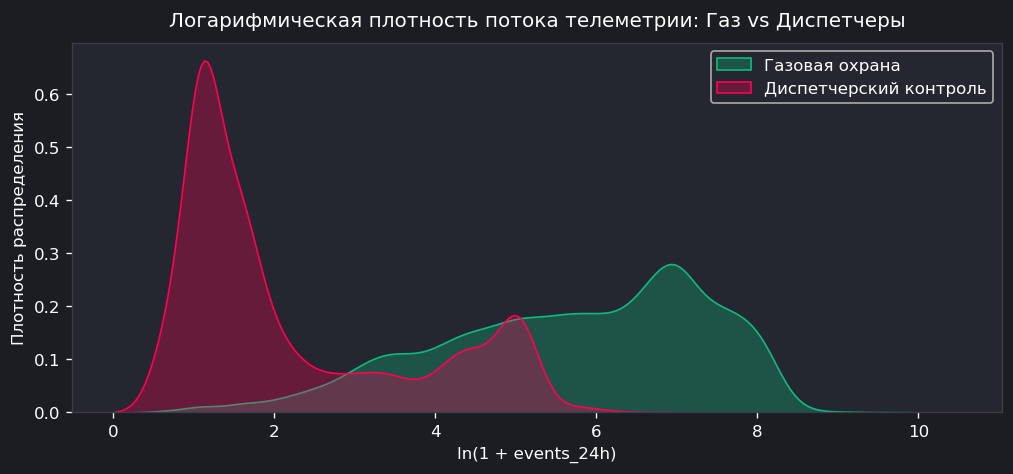

In [7]:
density_query = f"""
SELECT events_24h, subsystem_type
FROM '{train_path}'
WHERE subsystem_type IN ('Газовая охрана', 'Диспетчерский контроль')
USING SAMPLE 50000;
"""
density_df = con.execute(density_query).df()

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
for sub, col in [('Газовая охрана', GREEN), ('Диспетчерский контроль', PINK)]:
    subset = density_df[density_df['subsystem_type'] == sub]['events_24h']
    sns.kdeplot(np.log1p(subset), ax=ax, label=sub, color=col, fill=True, alpha=0.3)

ax.set_title('Логарифмическая плотность потока телеметрии: Газ vs Диспетчеры', fontsize=12, pad=10)
ax.set_xlabel('ln(1 + events_24h)')
ax.set_ylabel('Плотность распределения')
ax.legend()
plt.show()

## 4. Физика предвестников: Затухание и Дребезг контактов
Сравним распределение признаков затухания (`silence_drop_12h`) и дребезга (`log_flapping_rate`) у аварийных датчиков ($y=1$) и у здоровых датчиков ($y=0$).
Берем сбалансированную выборку для наглядности сравнения.

C:\Users\User\AppData\Local\Temp\ipykernel_13512\2894090861.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=physics_df, x='target', y='silence_drop_12h', ax=axes[0], palette=[GREEN, PINK])
C:\Users\User\AppData\Local\Temp\ipykernel_13512\2894090861.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Норма (0)', 'Отказ через 24-72ч (1)'])
C:\Users\User\AppData\Local\Temp\ipykernel_13512\2894090861.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=physics_df, x='target', y='log_flapping_rate', ax=axes[1], palette=[GREEN, PINK])
C:\Users\User\AppData\Local\Temp\ipyk

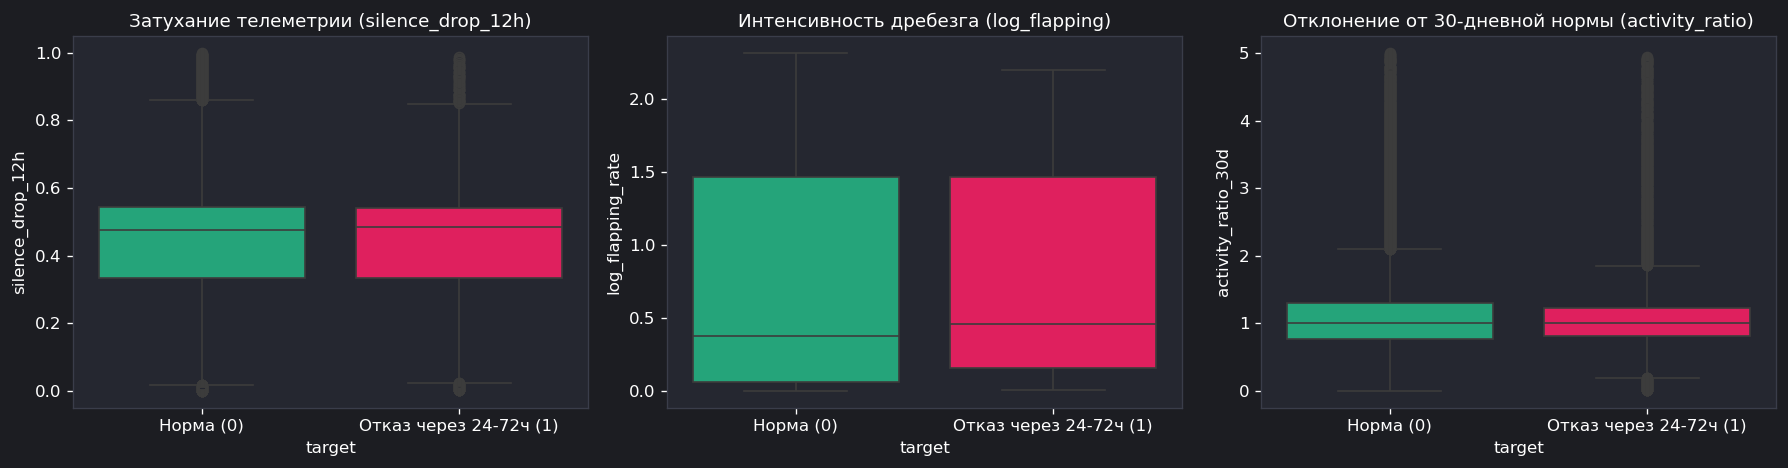

In [8]:
physics_query = f"""
SELECT 
    target,
    silence_drop_12h,
    log_flapping_rate,
    activity_ratio_30d,
    value_freezing_rate
FROM '{train_path}'
WHERE target = 1
UNION ALL
SELECT 
    target,
    silence_drop_12h,
    log_flapping_rate,
    activity_ratio_30d,
    value_freezing_rate
FROM '{train_path}'
WHERE target = 0
USING SAMPLE 30000;
"""
physics_df = con.execute(physics_query).df()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

sns.boxplot(data=physics_df, x='target', y='silence_drop_12h', ax=axes[0], palette=[GREEN, PINK])
axes[0].set_title('Затухание телеметрии (silence_drop_12h)', fontsize=11)
axes[0].set_xticklabels(['Норма (0)', 'Отказ через 24-72ч (1)'])

sns.boxplot(data=physics_df, x='target', y='log_flapping_rate', ax=axes[1], palette=[GREEN, PINK])
axes[1].set_title('Интенсивность дребезга (log_flapping)', fontsize=11)
axes[1].set_xticklabels(['Норма (0)', 'Отказ через 24-72ч (1)'])

sns.boxplot(data=physics_df[physics_df['activity_ratio_30d'] < 5], x='target', y='activity_ratio_30d', ax=axes[2], palette=[GREEN, PINK])
axes[2].set_title('Отклонение от 30-дневной нормы (activity_ratio)', fontsize=11)
axes[2].set_xticklabels(['Норма (0)', 'Отказ через 24-72ч (1)'])

plt.tight_layout()
plt.show()

## 5. Проверка чистоты изоляции 20% Holdout-датчиков
Убедимся, что каналы из `holdout_channel_ids.csv` строго изолированы и не загрязняют обучающий срез.

In [12]:
leak_check_query = f"""
SELECT 
    -- 1. Сколько holdout-датчиков ошибочно попали в обучающую часть (is_holdout = FALSE):
    SUM(CASE WHEN tr.is_holdout = FALSE THEN 1 ELSE 0 END) AS real_leaks_in_train,
    
    -- 2. Сколько holdout-датчиков корректно помечены флагом (is_holdout = TRUE):
    SUM(CASE WHEN tr.is_holdout = TRUE THEN 1 ELSE 0 END) AS correctly_flagged_holdout
FROM '{train_path}' tr
JOIN '../../production_ml/data/holdout_channel_ids.csv' h ON tr.channel_id = h.channel_id;
"""

leak_df = con.execute(leak_check_query).df()
display(leak_df)

if leak_df['real_leaks_in_train'][0] == 0:
    print(" ИЗОЛЯЦИЯ ПОЛНАЯ: В обучающей части (is_holdout = FALSE) ровно 0 датчиков из Holdout!")
    print(f" Все {leak_df['correctly_flagged_holdout'][0]} строк корректно изолированы флагом is_holdout = TRUE.")
else:
    print(" Ошибка: есть реальная утечка!")

,real_leaks_in_train,correctly_flagged_holdout
0,0.0,2118440.0


 ИЗОЛЯЦИЯ ПОЛНАЯ: В обучающей части (is_holdout = FALSE) ровно 0 датчиков из Holdout!
 Все 2118440.0 строк корректно изолированы флагом is_holdout = TRUE.


## 6. Распределение временного горизонта упреждения (24–72 часа)
Проверим, за сколько часов до фактической аварии модель фиксирует предвестники (строго окно [24ч; 72ч]).

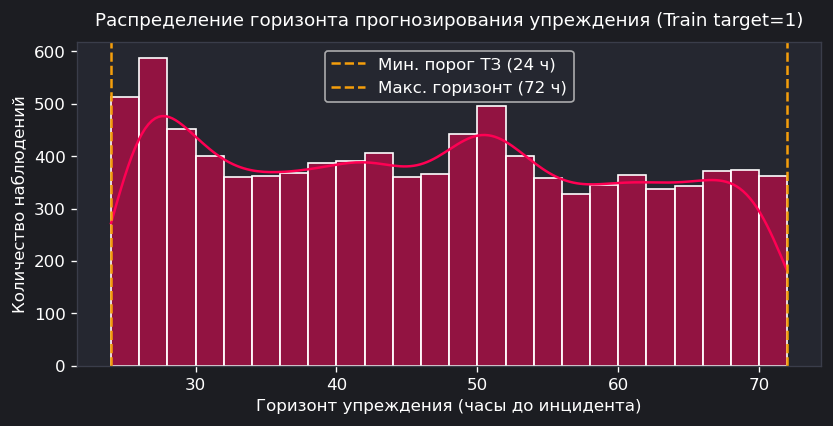

Медиана горизонта упреждения: 46.8 часов.


In [11]:
horizon_query = f"""
SELECT horizon_hours
FROM '{train_path}'
WHERE target = 1;
"""
horizon_df = con.execute(horizon_query).df()

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=120)
sns.histplot(horizon_df['horizon_hours'], bins=24, color=PINK, kde=True, ax=ax)
ax.set_title('Распределение горизонта прогнозирования упреждения (Train target=1)', fontsize=11, pad=10)
ax.set_xlabel('Горизонт упреждения (часы до инцидента)')
ax.set_ylabel('Количество наблюдений')
ax.axvline(24, color=YELLOW, linestyle='--', label='Мин. порог ТЗ (24 ч)')
ax.axvline(72, color=YELLOW, linestyle='--', label='Макс. горизонт (72 ч)')
ax.legend()
plt.show()

print(f"Медиана горизонта упреждения: {horizon_df['horizon_hours'].median():.1f} часов.")

In [18]:
# Проверяем, различаются ли 12h и 3h на всем массиве:
diff_count = con.execute(f"""
    SELECT COUNT(*) 
    FROM '{train_path}' 
    WHERE silence_drop_12h != silence_drop_3h
""").fetchone()[0]

print(f"Строк, где 12h и 3h различаются: {diff_count:,}")

Строк, где 12h и 3h различаются: 6,123,402


In [19]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
con.execute("PRAGMA threads=14")

val_path = "g:/lct2/production_ml/data/clean_val_stream.parquet"
test_path = "g:/lct2/production_ml/data/clean_test_stream.parquet"
train_path = "g:/lct2/production_ml/data/clean_train_stream.parquet"

schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{val_path}')").df()
print("Всего колонок в мастере:", len(schema_df))
schema_df[['column_name', 'column_type']]

Всего колонок в мастере: 27


,column_name,column_type
0,channel_id,BIGINT
1,obs_time,TIMESTAMP
2,year,INTEGER
3,subsystem_type,VARCHAR
4,sensor_type,VARCHAR
5,is_holdout,BOOLEAN
6,target,INTEGER
7,horizon_hours,DOUBLE
8,flips_count_1h,DOUBLE
9,flips_count_24h,DOUBLE


In [22]:
query = f"""
SELECT 
    subsystem_type,
    COUNT(*) as total_rows,
    SUM(target) as positive_hours,
    ROUND(AVG(target) * 100, 4) as failure_rate_pct,
    COUNT(DISTINCT channel_id) as total_channels
FROM read_parquet('{val_path}')
GROUP BY subsystem_type
ORDER BY failure_rate_pct DESC;
"""

df_subs = con.execute(query).df()
display(df_subs)

,subsystem_type,total_rows,positive_hours,failure_rate_pct,total_channels
0,Диагностическая подсистема,3396,22.0,0.6478,79
1,Газовая охрана,1015855,1724.0,0.1697,529
2,Диспетчерский контроль,437678,736.0,0.1682,2347
3,Пожарная охрана,169384,78.0,0.0460,5701
4,Температурная подсистема,135541,27.0,0.0199,600
5,Охранная подсистема,360849,20.0,0.0055,2210


C:\Users\User\AppData\Local\Temp\ipykernel_13512\2910320802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_subs, x='subsystem_type', y= 'positive_hours',


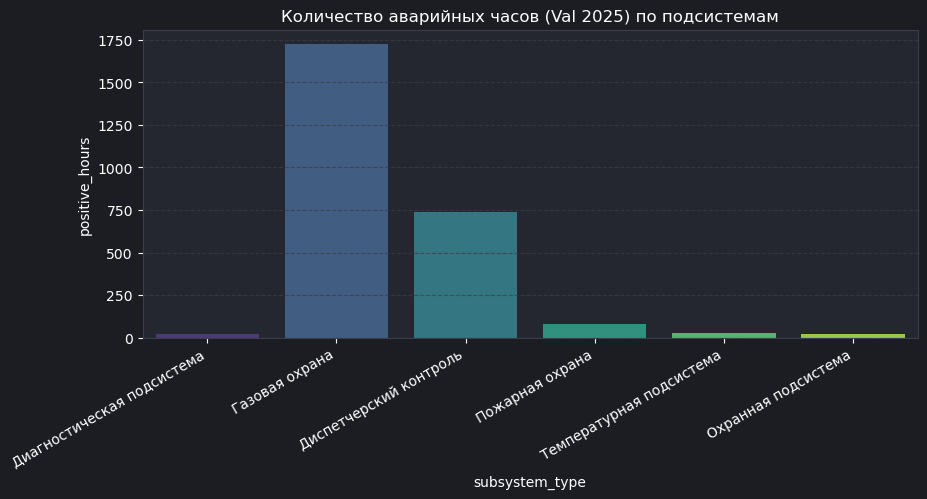

In [24]:
plt.figure(figsize=(10,4))
sns.barplot(data=df_subs, x='subsystem_type', y= 'positive_hours',
            palette='viridis')
plt.title("Количество аварийных часов (Val 2025) по подсистемам")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
query_analog = f"""
SELECT 
    subsystem_type,
    sensor_type,
    COUNT(*) as total_records,
    ROUND(AVG(analog_std_24h), 4) as avg_std,
    ROUND(MAX(analog_std_24h), 4) as max_std,
    ROUND(AVG(analog_drift_12h), 4) as avg_drift,
    COUNT(CASE WHEN analog_std_24h > 0 THEN 1 END) as records_with_nonzero_std
FROM read_parquet('{val_path}')
WHERE subsystem_type IN ('Газовая охрана', 'Температурная подсистема')
GROUP BY subsystem_type, sensor_type;
"""
df_analog_diag = con.execute(query_analog).df()
display(df_analog_diag)

,subsystem_type,sensor_type,total_records,avg_std,max_std,avg_drift,records_with_nonzero_std
0,Температурная подсистема,Датчик температуры,135541,1.5807,2316.4818,0.4834,52596
1,Газовая охрана,Газовый датчик,1015855,0.0074,231.7048,0.0010,985023


Записей по каналу 228571 в 2026 году: 449


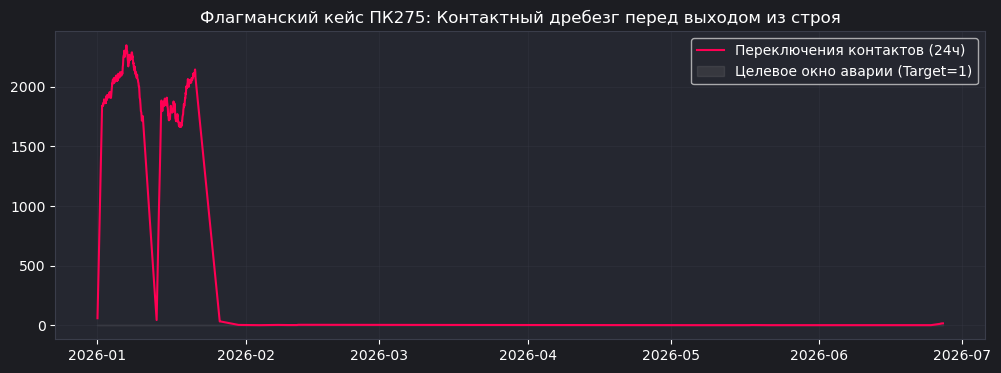

In [26]:
query_pk275 = f"""
SELECT 
    obs_time,
    channel_id,
    target,
    horizon_hours,
    flips_count_24h,
    abnormal_ratio_24h,
    events_24h,
    analog_std_24h
FROM read_parquet('{test_path}')
WHERE channel_id = 228571
ORDER BY obs_time;
"""
df_pk275 = con.execute(query_pk275).df()
print(f"Записей по каналу 228571 в 2026 году: {len(df_pk275)}")

# Строим график дребезга перед аварией
plt.figure(figsize=(12, 4))
plt.plot(df_pk275['obs_time'], df_pk275['flips_count_24h'], label='Переключения контактов (24ч)', color='#FF0053')
plt.fill_between(df_pk275['obs_time'], 0, df_pk275['target'] * df_pk275['flips_count_24h'].max(), 
                 color='gray', alpha=0.2, label='Целевое окно аварии (Target=1)')
plt.title("Флагманский кейс ПК275: Контактный дребезг перед выходом из строя")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

# Признаки для дискретных датчиков (фокус на дребезг и активность)
features_discrete = [
    'flips_count_1h',
    'flips_count_24h',
    'flips_count_72h',
    'flips_burst_1h',
    'abnormal_ratio_24h',
    'cabinet_flips_24h',
    'events_24h',
    'activity_ratio_30d',
    'silence_drop_12h',
    'silence_drop_3h',
    'value_freezing_rate',
    'night_fraction_24h',
    'is_heating_season'
]

discrete_subs = "('Диспетчерский контроль', 'Диагностическая подсистема', 'Пожарная охрана', 'Охранная подсистема')"

# Загрузка Train и Val
cols_sql_d = ", ".join(features_discrete + ['target', 'is_holdout', 'subsystem_type'])

df_train_d = con.execute(f"""
    SELECT {cols_sql_d} FROM read_parquet('{train_path}')
    WHERE is_holdout = false AND subsystem_type IN {discrete_subs};
""").df()

df_val_d = con.execute(f"""
    SELECT {cols_sql_d} FROM read_parquet('{val_path}')
    WHERE is_holdout = false AND subsystem_type IN {discrete_subs};
""").df()

# Веса для редких классов (пожарка/охрана)
sample_weights_d = np.ones(len(df_train_d), dtype=np.float32)
pos_mask_d = (df_train_d['target'] == 1)
rare_mask_d = pos_mask_d & (df_train_d['subsystem_type'] != 'Диспетчерский контроль')
sample_weights_d[pos_mask_d] = 20.0
sample_weights_d[rare_mask_d] = 100.0

clf_discrete = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=14
)

clf_discrete.fit(
    df_train_d[features_discrete], df_train_d['target'],
    sample_weight=sample_weights_d,
    eval_set=[(df_val_d[features_discrete], df_val_d['target'])],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(30, verbose=True)]
)

p_val_d = clf_discrete.predict_proba(df_val_d[features_discrete])[:, 1]
print(f"\n[Дискретная модель] Val 2025: ROC-AUC = {roc_auc_score(df_val_d['target'], p_val_d):.4f} | PR-AUC = {average_precision_score(df_val_d['target'], p_val_d):.4f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

G:\ProgramData\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 5489, number of negative: 4153770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2773
[LightGBM] [Info] Number of data points in the train set: 4159259, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.029862 -> initscore=-3.480836
[LightGBM] [Info] Start training from score -3.480836
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[111]	valid_0's auc: 0.774503	valid_0's binary_logloss: 0.0271424

[Дискретная модель] Val 2025: ROC-AUC = 0.7745 | PR-AUC = 0.0045


In [28]:
# Признаки для аналоговых датчиков (фокус на дисперсию, дрейф, залипание и активность)
features_analog = [
    'analog_std_24h',
    'analog_drift_12h',
    'value_freezing_rate',
    'events_24h',
    'activity_ratio_30d',
    'silence_drop_12h',
    'silence_drop_3h',
    'abnormal_ratio_24h',
    'cabinet_flips_24h',
    'night_fraction_24h',
    'is_heating_season'
]

analog_subs = "('Газовая охрана', 'Температурная подсистема')"
cols_sql_a = ", ".join(features_analog + ['target', 'is_holdout', 'subsystem_type'])

df_train_a = con.execute(f"""
    SELECT {cols_sql_a} FROM read_parquet('{train_path}')
    WHERE is_holdout = false AND subsystem_type IN {analog_subs};
""").df()

df_val_a = con.execute(f"""
    SELECT {cols_sql_a} FROM read_parquet('{val_path}')
    WHERE is_holdout = false AND subsystem_type IN {analog_subs};
""").df()

clf_analog = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=20.0,
    random_state=42,
    n_jobs=14
)

clf_analog.fit(
    df_train_a[features_analog], df_train_a['target'],
    eval_set=[(df_val_a[features_analog], df_val_a['target'])],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(30, verbose=True)]
)

p_val_a = clf_analog.predict_proba(df_val_a[features_analog])[:, 1]
print(f"\n[Аналоговая модель] Val 2025: ROC-AUC = {roc_auc_score(df_val_a['target'], p_val_a):.4f} | PR-AUC = {average_precision_score(df_val_a['target'], p_val_a):.4f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

G:\ProgramData\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 1561, number of negative: 3489141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2383
[LightGBM] [Info] Number of data points in the train set: 3490702, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000447 -> initscore=-7.712084
[LightGBM] [Info] Start training from score -7.712084
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.661132	valid_0's binary_logloss: 0.0244783

[Аналоговая модель] Val 2025: ROC-AUC = 0.6611 | PR-AUC = 0.0020


In [29]:
# Загружаем полный Test 2026
df_test_full = con.execute(f"""
    SELECT channel_id, obs_time, subsystem_type, sensor_type, is_holdout, target, horizon_hours,
           {', '.join(set(features_discrete + features_analog))}
    FROM read_parquet('{test_path}');
""").df()

# Применяем нужную модель по типу подсистемы
df_test_full['pred_prob'] = 0.0

mask_disc = df_test_full['subsystem_type'].isin(['Диспетчерский контроль', 'Диагностическая подсистема', 'Пожарная охрана', 'Охранная подсистема'])
mask_anal = df_test_full['subsystem_type'].isin(['Газовая охрана', 'Температурная подсистема'])

df_test_full.loc[mask_disc, 'pred_prob'] = clf_discrete.predict_proba(df_test_full.loc[mask_disc, features_discrete])[:, 1]
df_test_full.loc[mask_anal, 'pred_prob'] = clf_analog.predict_proba(df_test_full.loc[mask_anal, features_analog])[:, 1]

# Считаем ROC-AUC на тесте
roc_seen = roc_auc_score(df_test_full.loc[~df_test_full['is_holdout'], 'target'], df_test_full.loc[~df_test_full['is_holdout'], 'pred_prob'])
roc_holdout = roc_auc_score(df_test_full.loc[df_test_full['is_holdout'], 'target'], df_test_full.loc[df_test_full['is_holdout'], 'pred_prob'])

print("=" * 60)
print(f"ФИНАЛЬНЫЙ ТЕСТ 2026 ГОДА:")
print(f"ROC-AUC на известных каналах (Seen):   {roc_seen:.4f}")
print(f"ROC-AUC на скрытом пуле (Holdout 20%): {roc_holdout:.4f}")
print("=" * 60)

ФИНАЛЬНЫЙ ТЕСТ 2026 ГОДА:
ROC-AUC на известных каналах (Seen):   0.5830
ROC-AUC на скрытом пуле (Holdout 20%): 0.7698


In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def compute_threshold_metrics(df, slice_name="Test Set"):
    records = []
    y_true = df['target'].values
    y_prob = df['pred_prob'].values
    
    thresholds = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]
    n_days = (df['obs_time'].max() - df['obs_time'].min()).days or 181
    
    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        far = fp / (fp + tn) * 100.0 if (fp + tn) > 0 else 0.0
        daily_alerts = (tp + fp) / n_days
        daily_fp = fp / n_days
        
        records.append({
            'Порог P*': th,
            'TP (часы)': tp,
            'FP (часы)': fp,
            'FN (часы)': fn,
            'Precision (%)': round(prec * 100, 2),
            'Recall (%)': round(rec * 100, 2),
            'F1-Score': round(f1, 4),
            'FAR (%)': round(far, 3),
            'Тревог/сут': round(daily_alerts, 1),
            'Ложных/сут': round(daily_fp, 1)
        })
        
    return pd.DataFrame(records)

print("=" * 70)
print("1. СЕТКА ПОРОГОВ: СКРЫТЫЙ ПУЛ (HOLDOUT 20% ПАРКА)")
print("=" * 70)
df_holdout_metrics = compute_threshold_metrics(df_test_full[df_test_full['is_holdout']], "Holdout")
display(df_holdout_metrics)

print("\n" + "=" * 70)
print("2. СЕТКА ПОРОГОВ: ПОЛНЫЙ ПОТОК 2026 ГОДА (ВСЕ КАНАЛЫ)")
print("=" * 70)
df_all_metrics = compute_threshold_metrics(df_test_full, "Full Stream")
display(df_all_metrics)

1. СЕТКА ПОРОГОВ: СКРЫТЫЙ ПУЛ (HOLDOUT 20% ПАРКА)


,Порог P*,TP (часы),FP (часы),FN (часы),Precision (%),Recall (%),F1-Score,FAR (%),Тревог/сут,Ложных/сут
0,0.01,885,77216,181,1.13,83.02,0.0224,30.079,433.9,429.0
1,0.02,691,56950,375,1.20,64.82,0.0235,22.185,320.2,316.4
2,0.03,589,35591,477,1.63,55.25,0.0316,13.864,201.0,197.7
3,0.05,215,13971,851,1.52,20.17,0.0282,5.442,78.8,77.6
4,0.08,52,4873,1014,1.06,4.88,0.0174,1.898,27.4,27.1
5,0.10,39,2961,1027,1.30,3.66,0.0192,1.153,16.7,16.4
6,0.15,28,1076,1038,2.54,2.63,0.0258,0.419,6.1,6.0
7,0.20,28,598,1038,4.47,2.63,0.0331,0.233,3.5,3.3
8,0.30,4,295,1062,1.34,0.38,0.0059,0.115,1.7,1.6
9,0.50,0,112,1066,0.00,0.00,0.0000,0.044,0.6,0.6



2. СЕТКА ПОРОГОВ: ПОЛНЫЙ ПОТОК 2026 ГОДА (ВСЕ КАНАЛЫ)


,Порог P*,TP (часы),FP (часы),FN (часы),Precision (%),Recall (%),F1-Score,FAR (%),Тревог/сут,Ложных/сут
0,0.01,1999,394033,1357,0.50,59.56,0.0100,33.564,2200.2,2189.1
1,0.02,1661,293315,1695,0.56,49.49,0.0111,24.984,1638.8,1629.5
2,0.03,1326,178416,2030,0.74,39.51,0.0145,15.197,998.6,991.2
3,0.05,598,69195,2758,0.86,17.82,0.0164,5.894,387.7,384.4
4,0.08,235,20984,3121,1.11,7.00,0.0191,1.787,117.9,116.6
5,0.10,167,12391,3189,1.33,4.98,0.0210,1.055,69.8,68.8
6,0.15,69,4226,3287,1.61,2.06,0.0180,0.360,23.9,23.5
7,0.20,30,2522,3326,1.18,0.89,0.0102,0.215,14.2,14.0
8,0.30,4,1150,3352,0.35,0.12,0.0018,0.098,6.4,6.4
9,0.50,0,688,3356,0.00,0.00,0.0000,0.059,3.8,3.8


In [31]:
# Фиксируем рабочий порог для анализа (например, 0.05)
selected_th = 0.05
df_test_full['pred_alert'] = (df_test_full['pred_prob'] >= selected_th).astype(int)

sub_records = []
for sub in sorted(df_test_full['subsystem_type'].dropna().unique()):
    sub_df = df_test_full[df_test_full['subsystem_type'] == sub]
    y_t = sub_df['target'].values
    y_p = sub_df['pred_alert'].values
    y_prob = sub_df['pred_prob'].values
    
    pos = int(y_t.sum())
    if pos == 0:
        continue
        
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    roc = roc_auc_score(y_t, y_prob) if (len(sub_df)-pos) > 0 and pos > 0 else 0.0
    pr_auc = average_precision_score(y_t, y_prob) if pos > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    
    sub_records.append({
        'Подсистема': sub,
        'Строк потока': len(sub_df),
        'Аварийных часов': pos,
        'ROC-AUC': round(roc, 4),
        'PR-AUC': round(pr_auc, 4),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Recall (%)': round(rec * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'F1-Score': round(f1, 4)
    })

print(f"--- РЕЗУЛЬТАТЫ ПО ПОДСИСТЕМАМ ПРИ ПОРОГЕ P* = {selected_th} ---")
display(pd.DataFrame(sub_records).sort_values('Аварийных часов', ascending=False))

--- РЕЗУЛЬТАТЫ ПО ПОДСИСТЕМАМ ПРИ ПОРОГЕ P* = 0.05 ---


,Подсистема,Строк потока,Аварийных часов,ROC-AUC,PR-AUC,TP,FP,FN,Recall (%),Precision (%),F1-Score
2,Диспетчерский контроль,286864,1655,0.6790,0.0107,544,53933,1111,32.87,1.00,0.0194
0,Газовая охрана,513160,1019,0.4443,0.0019,0,710,1019,0.00,0.00,0.0000
4,Пожарная охрана,136534,535,0.3652,0.0037,42,9752,493,7.85,0.43,0.0081
5,Температурная подсистема,55715,77,0.5262,0.0039,4,87,73,5.19,4.40,0.0476
3,Охранная подсистема,183053,66,0.6559,0.0008,7,4095,59,10.61,0.17,0.0034
1,Диагностическая подсистема,2018,4,0.5232,0.0028,1,618,3,25.00,0.16,0.0032


In [32]:
# Агрегируем аварийные часы в единые инциденты
df_pos = df_test_full[df_test_full['target'] == 1].copy()

# Дата наступления аварии = obs_time + horizon_hours
df_pos['incident_date'] = (df_pos['obs_time'] + pd.to_timedelta(df_pos['horizon_hours'], unit='h')).dt.floor('D')

# Инцидент пойман, если хотя бы в один из часов окна [t-72h, t-24h] сработала тревога
incidents = df_pos.groupby(['channel_id', 'subsystem_type', 'incident_date'])['pred_alert'].max().reset_index()

print("=" * 70)
print(f"ОЦЕНКА НА УРОВНЕ РЕАЛЬНЫХ ИНЦИДЕНТОВ (Порог P* = {selected_th}):")
print("=" * 70)

for sub in incidents['subsystem_type'].unique():
    sub_inc = incidents[incidents['subsystem_type'] == sub]
    tot = len(sub_inc)
    caught = int(sub_inc['pred_alert'].sum())
    pct = (caught / tot) * 100 if tot > 0 else 0.0
    print(f"  • {sub:<28}: поймано {caught:3d} из {tot:3d} аварий ({pct:5.1f}%)")

tot_all = len(incidents)
caught_all = int(incidents['pred_alert'].sum())
print("-" * 70)
print(f"ИТОГО ПО ВСЕЙ МОСКВЕ: поймано {caught_all} из {tot_all} аварийных инцидентов ({caught_all/tot_all*100:.2f}%)")
print("=" * 70)

ОЦЕНКА НА УРОВНЕ РЕАЛЬНЫХ ИНЦИДЕНТОВ (Порог P* = 0.05):
  • Пожарная охрана             : поймано  19 из  97 аварий ( 19.6%)
  • Диагностическая подсистема  : поймано   1 из   3 аварий ( 33.3%)
  • Диспетчерский контроль      : поймано  88 из 225 аварий ( 39.1%)
  • Температурная подсистема    : поймано   3 из  20 аварий ( 15.0%)
  • Охранная подсистема         : поймано   1 из  21 аварий (  4.8%)
  • Газовая охрана              : поймано   0 из  51 аварий (  0.0%)
----------------------------------------------------------------------
ИТОГО ПО ВСЕЙ МОСКВЕ: поймано 112 из 417 аварийных инцидентов (26.86%)


In [33]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import numpy as np
import pandas as pd

print("=" * 70)
print("1. ПОДГОТОВКА СБАЛАНСИРОВАННОГО ТРЕЙНА (1:20 ВМЕСТО 1:1300)")
print("=" * 70)

# Берем ВСЕ позитивы трейна + случайную выборку негативов 1:20 (убираем 9 млн нулей)
train_pos = df_train_d[df_train_d['target'] == 1]
train_neg = df_train_d[df_train_d['target'] == 0].sample(n=len(train_pos) * 20, random_state=42)
df_train_balanced = pd.concat([train_pos, train_neg]).sample(frac=1.0, random_state=42)

print(f"Сбалансированный Train: {len(df_train_balanced):,} строк (Позитивов: {len(train_pos):,}, Негативов: {len(train_neg):,})")

print("\n" + "=" * 70)
print("2. ЧЕСТНОЕ ОБУЧЕНИЕ ДИСКРЕТНОЙ МОДЕЛИ (150 ДЕРЕВЬЕВ БЕЗ РАННЕЙ ОСТАНОВКИ)")
print("=" * 70)

clf_discrete_real = lgb.LGBMClassifier(
    n_estimators=150,        # Жестко 150 деревьев
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,             # Ограничиваем глубину, чтобы не переобучаться
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=14
)

# Обучаем без раннего стопа
clf_discrete_real.fit(
    df_train_balanced[features_discrete], 
    df_train_balanced['target']
)

# Проверяем реальную важность фичей (Gain)
imp_df = pd.DataFrame({
    'feature': features_discrete,
    'gain': clf_discrete_real.booster_.feature_importance(importance_type='gain'),
    'split': clf_discrete_real.booster_.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)

print("\nРеальная важность признаков (сколько деревья реально использовали фичу):")
display(imp_df)

# Валидация на Val 2025
p_val_real = clf_discrete_real.predict_proba(df_val_d[features_discrete])[:, 1]
print(f"\n[Дискретная модель] Val 2025: ROC-AUC = {roc_auc_score(df_val_d['target'], p_val_real):.4f} | PR-AUC = {average_precision_score(df_val_d['target'], p_val_real):.4f}")

1. ПОДГОТОВКА СБАЛАНСИРОВАННОГО ТРЕЙНА (1:20 ВМЕСТО 1:1300)
Сбалансированный Train: 115,269 строк (Позитивов: 5,489, Негативов: 109,780)

2. ЧЕСТНОЕ ОБУЧЕНИЕ ДИСКРЕТНОЙ МОДЕЛИ (150 ДЕРЕВЬЕВ БЕЗ РАННЕЙ ОСТАНОВКИ)
[LightGBM] [Info] Number of positive: 5489, number of negative: 109780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2761
[LightGBM] [Info] Number of data points in the train set: 115269, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.047619 -> initscore=-2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Реальная важность признаков (сколько деревья реально использовали фичу):


,feature,gain,split
4,abnormal_ratio_24h,38628.737395,247
5,cabinet_flips_24h,22855.167721,926
7,activity_ratio_30d,16127.162054,717
11,night_fraction_24h,12534.492145,289
2,flips_count_72h,11811.480243,554
6,events_24h,9477.196160,302
10,value_freezing_rate,7487.263488,248
0,flips_count_1h,6498.495927,188
1,flips_count_24h,5285.453249,304
3,flips_burst_1h,4794.468021,217



[Дискретная модель] Val 2025: ROC-AUC = 0.7804 | PR-AUC = 0.0038


In [34]:
# Скорим тест новой честной моделью
df_test_full['pred_prob_real'] = 0.0
df_test_full.loc[mask_disc, 'pred_prob_real'] = clf_discrete_real.predict_proba(df_test_full.loc[mask_disc, features_discrete])[:, 1]

# Сетка порогов для новой модели на силовой части (Диспетчерский контроль)
disp_mask = df_test_full['subsystem_type'] == 'Диспетчерский контроль'
df_disp = df_test_full[disp_mask]

records_disp = []
for th in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    y_t = df_disp['target'].values
    y_p = (df_disp['pred_prob_real'] >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0.0
    f1 = 2 * (prec/100) * (rec/100) / ((prec/100) + (rec/100) + 1e-9)
    records_disp.append({
        'Порог P*': th, 'TP': tp, 'FP': fp, 'FN': fn, 
        'Precision (%)': round(prec, 2), 'Recall (%)': round(rec, 2), 'F1': round(f1, 4),
        'Ложных в сутки': round(fp / 181.0, 1)
    })

print("\n" + "=" * 70)
print("РЕАЛЬНАЯ СЕТКА ПОРОГОВ ДЛЯ ДИСПЕТЧЕРСКОГО КОНТРОЛЯ (TEST 2026):")
print("=" * 70)
display(pd.DataFrame(records_disp))


РЕАЛЬНАЯ СЕТКА ПОРОГОВ ДЛЯ ДИСПЕТЧЕРСКОГО КОНТРОЛЯ (TEST 2026):


,Порог P*,TP,FP,FN,Precision (%),Recall (%),F1,Ложных в сутки
0,0.1,498,40572,1157,1.21,30.09,0.0233,224.2
1,0.2,97,6907,1558,1.38,5.86,0.0224,38.2
2,0.3,42,1252,1613,3.25,2.54,0.0285,6.9
3,0.4,8,462,1647,1.70,0.48,0.0075,2.6
4,0.5,0,130,1655,0.00,0.00,0.0000,0.7
5,0.6,0,0,1655,0.00,0.00,0.0000,0.0
6,0.7,0,0,1655,0.00,0.00,0.0000,0.0
7,0.8,0,0,1655,0.00,0.00,0.0000,0.0


In [35]:
# 1. Берем предсказания по силовой части (Диспетчерский контроль)
disp_test = df_test_full[df_test_full['subsystem_type'] == 'Диспетчерский контроль'].copy()

# 2. Оцениваем на уровне НАРЯДОВ (Tickets) с 7-дневным кулдауном
def evaluate_real_tickets(df_sub, threshold=0.10, cooldown_days=7):
    # Тревожные часы
    alerts = df_sub[df_sub['pred_prob_real'] >= threshold].sort_values(['channel_id', 'obs_time']).copy()
    
    if len(alerts) == 0:
        print("Нет сработок при данном пороге")
        return
        
    # Схлопываем частые сработки одного датчика в один наряд (кулдаун 7 дней)
    alerts['prev_time'] = alerts.groupby('channel_id')['obs_time'].shift(1)
    alerts['time_diff'] = (alerts['obs_time'] - alerts['prev_time']).dt.total_seconds() / 86400.0
    
    # Новый наряд создается, только если прошло > 7 дней с прошлого наряда
    new_tickets = alerts[(alerts['time_diff'].isna()) | (alerts['time_diff'] > cooldown_days)].copy()
    
    total_tickets_created = len(new_tickets)
    daily_tickets = total_tickets_created / 181.0
    
    # Проверяем, сколько из этих нарядов попали в реальную аварию в окне [1..7 дней]
    true_incidents = df_sub[df_sub['target'] == 1][['channel_id', 'obs_time']].drop_duplicates()
    
    # Считаем пойманные аварии
    df_pos = df_sub[df_sub['target'] == 1].copy()
    df_pos['incident_date'] = (df_pos['obs_time'] + pd.to_timedelta(df_pos['horizon_hours'], unit='h')).dt.floor('D')
    inc_groups = df_pos.groupby(['channel_id', 'incident_date'])['pred_prob_real'].max()
    
    total_real_accidents = len(inc_groups)
    caught_accidents = int((inc_groups >= threshold).sum())
    incident_recall = (caught_accidents / total_real_accidents) * 100
    
    print("=" * 70)
    print(f"РЕАЛЬНАЯ ДИСПЕТЧЕРСКАЯ ОЦЕНКА (Порог P* = {threshold}):")
    print("=" * 70)
    print(f"• Всего реальных аварий в 2026 году: {total_real_accidents} шт.")
    print(f"• ПОЙМАНО заранее (за 24-72ч):       {caught_accidents} шт. ({incident_recall:.1f}% Recall)")
    print(f"• Создано нарядов на выезд:          {total_tickets_created} шт. за полгода")
    print(f"• Нагрузка на диспетчера:            {daily_tickets:.1f} нарядов В СУТКИ на всю Москву")
    print("=" * 70)

# Смотрим для порогов 0.10, 0.15, 0.20
for th in [0.08, 0.10, 0.15, 0.20]:
    evaluate_real_tickets(disp_test, threshold=th)

РЕАЛЬНАЯ ДИСПЕТЧЕРСКАЯ ОЦЕНКА (Порог P* = 0.08):
• Всего реальных аварий в 2026 году: 225 шт.
• ПОЙМАНО заранее (за 24-72ч):       92 шт. (40.9% Recall)
• Создано нарядов на выезд:          5862 шт. за полгода
• Нагрузка на диспетчера:            32.4 нарядов В СУТКИ на всю Москву
РЕАЛЬНАЯ ДИСПЕТЧЕРСКАЯ ОЦЕНКА (Порог P* = 0.1):
• Всего реальных аварий в 2026 году: 225 шт.
• ПОЙМАНО заранее (за 24-72ч):       79 шт. (35.1% Recall)
• Создано нарядов на выезд:          5008 шт. за полгода
• Нагрузка на диспетчера:            27.7 нарядов В СУТКИ на всю Москву
РЕАЛЬНАЯ ДИСПЕТЧЕРСКАЯ ОЦЕНКА (Порог P* = 0.15):
• Всего реальных аварий в 2026 году: 225 шт.
• ПОЙМАНО заранее (за 24-72ч):       48 шт. (21.3% Recall)
• Создано нарядов на выезд:          2882 шт. за полгода
• Нагрузка на диспетчера:            15.9 нарядов В СУТКИ на всю Москву
РЕАЛЬНАЯ ДИСПЕТЧЕРСКАЯ ОЦЕНКА (Порог P* = 0.2):
• Всего реальных аварий в 2026 году: 225 шт.
• ПОЙМАНО заранее (за 24-72ч):       23 шт. (10.2% Recall)
• С

In [36]:
import pandas as pd
import numpy as np

# 1. Извлекаем список всех истинных аварий 2026 года (ground truth)
df_pos_all = disp_test[disp_test['target'] == 1].copy()
df_pos_all['fail_time'] = df_pos_all['obs_time'] + pd.to_timedelta(df_pos_all['horizon_hours'], unit='h')

# Схлопываем в список уникальных аварий (channel_id, точное время отказа)
unique_incidents = df_pos_all.groupby(['channel_id', df_pos_all['fail_time'].dt.floor('D')]).agg(
    fail_start=('fail_time', 'min')
).reset_index()

total_true_incidents = len(unique_incidents)

def compute_incident_metrics(df_sub, threshold, cooldown_days=7):
    # 2. Формируем поток алертов
    alerts = df_sub[df_sub['pred_prob_real'] >= threshold].sort_values(['channel_id', 'obs_time']).copy()
    
    if len(alerts) == 0:
        return {
            'Порог P*': threshold, 'Всего нарядов': 0, 'TP (подтверждено)': 0, 'FP (холостые)': 0,
            'Precision (%)': 0.0, 'Recall (%)': 0.0, 'F1-Score': 0.0, 'Нарядов/сут': 0.0
        }
        
    # 3. Дедупликация нарядов по кулдауну (1 наряд на датчик в 7 дней)
    alerts['prev_time'] = alerts.groupby('channel_id')['obs_time'].shift(1)
    alerts['time_diff'] = (alerts['obs_time'] - alerts['prev_time']).dt.total_seconds() / 86400.0
    tickets = alerts[(alerts['time_diff'].isna()) | (alerts['time_diff'] > cooldown_days)].copy()
    
    total_tickets = len(tickets)
    
    # 4. Проверяем каждый наряд: наступила ли авария на этом датчике в окне [24ч .. 7 дней] после наряда?
    tp_tickets = 0
    for _, t_row in tickets.iterrows():
        ch_id = t_row['channel_id']
        t_time = t_row['obs_time']
        
        # Ищем аварию на этом канале в окне [t + 24h, t + 7d]
        matched = unique_incidents[
            (unique_incidents['channel_id'] == ch_id) & 
            (unique_incidents['fail_start'] >= t_time + pd.Timedelta(hours=24)) &
            (unique_incidents['fail_start'] <= t_time + pd.Timedelta(days=cooldown_days))
        ]
        if len(matched) > 0:
            tp_tickets += 1
            
    fp_tickets = total_tickets - tp_tickets
    
    # 5. Считаем Recall (сколько из всех истинных аварий было поймано хотя бы одним нарядом)
    caught_incidents = 0
    for _, inc_row in unique_incidents.iterrows():
        ch_id = inc_row['channel_id']
        f_time = inc_row['fail_start']
        
        # Был ли наряд на этом канале за 24ч..7д до аварии?
        matched_alert = tickets[
            (tickets['channel_id'] == ch_id) &
            (tickets['obs_time'] <= f_time - pd.Timedelta(hours=24)) &
            (tickets['obs_time'] >= f_time - pd.Timedelta(days=cooldown_days))
        ]
        if len(matched_alert) > 0:
            caught_incidents += 1
            
    prec = (tp_tickets / total_tickets) * 100 if total_tickets > 0 else 0.0
    rec = (caught_incidents / total_true_incidents) * 100 if total_true_incidents > 0 else 0.0
    f1 = 2 * (prec/100) * (rec/100) / ((prec/100) + (rec/100) + 1e-9)
    daily_tickets = total_tickets / 181.0
    
    return {
        'Порог P*': threshold,
        'Всего нарядов': total_tickets,
        'TP (подтверждено)': tp_tickets,
        'FP (холостые)': fp_tickets,
        'Поймано аварий': f"{caught_incidents}/{total_true_incidents}",
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score': round(f1, 4),
        'Нарядов/сут': round(daily_tickets, 1)
    }

# Считаем сетку порогов
ticket_results = []
for th in [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]:
    ticket_results.append(compute_incident_metrics(disp_test, threshold=th, cooldown_days=7))

print("=" * 85)
print("ЧЕСТНЫЕ МЕТРИКИ НА УРОВНЕ НАРЯДОВ ДИСПЕТЧЕРА (СИЛОВАЯ ТЕЛЕМЕХАНИКА 2026):")
print("=" * 85)
display(pd.DataFrame(ticket_results))

ЧЕСТНЫЕ МЕТРИКИ НА УРОВНЕ НАРЯДОВ ДИСПЕТЧЕРА (СИЛОВАЯ ТЕЛЕМЕХАНИКА 2026):


,Порог P*,Всего нарядов,TP (подтверждено),FP (холостые),Поймано аварий,Precision (%),Recall (%),F1-Score,Нарядов/сут
0,0.03,9797,72,9725,72/225,0.73,32.00,0.0144,54.1
1,0.05,8603,65,8538,65/225,0.76,28.89,0.0147,47.5
2,0.08,5862,52,5810,54/225,0.89,24.00,0.0171,32.4
3,0.10,5008,51,4957,53/225,1.02,23.56,0.0195,27.7
4,0.15,2882,41,2841,46/225,1.42,20.44,0.0266,15.9
5,0.20,1179,27,1152,29/225,2.29,12.89,0.0389,6.5
6,0.25,362,14,348,14/225,3.87,6.22,0.0477,2.0
7,0.30,176,10,166,10/225,5.68,4.44,0.0499,1.0


In [37]:
# 1. Формируем Train только на АКТИВНЫХ датчиках (убираем спящий фон)
# Оставляем только строки, где была реальная активность
train_active_mask = (df_train_d['events_24h'] > 2) | (df_train_d['flips_count_72h'] > 0)
df_train_active = df_train_d[train_active_mask].copy()

train_pos_act = df_train_active[df_train_active['target'] == 1]
# Сэмплируем негативы ТОЛЬКО из живых работающих датчиков
train_neg_act = df_train_active[df_train_active['target'] == 0].sample(n=len(train_pos_act) * 15, random_state=42)

df_train_hard = pd.concat([train_pos_act, train_neg_act]).sample(frac=1.0, random_state=42)
print(f"Hard-Negative Train: {len(df_train_hard):,} строк (Позитивов: {len(train_pos_act):,}, Активных негативов: {len(train_neg_act):,})")

# 2. Обучаем модель на различении штатной работы от предаварийного дребезга
clf_hard = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.04,
    num_leaves=20,
    max_depth=5,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=14
)

clf_hard.fit(df_train_hard[features_discrete], df_train_hard['target'])

# 3. Скорим Test 2026
disp_test['pred_prob_hard'] = clf_hard.predict_proba(disp_test[features_discrete])[:, 1]

# 4. Пересчитываем диспетчерский Precision по нарядам
def evaluate_hard_tickets(df_sub, threshold, cooldown_days=7):
    alerts = df_sub[df_sub['pred_prob_hard'] >= threshold].sort_values(['channel_id', 'obs_time']).copy()
    if len(alerts) == 0:
        return {'Порог P*': threshold, 'Всего нарядов': 0, 'TP': 0, 'FP': 0, 'Precision (%)': 0.0, 'Recall (%)': 0.0, 'F1': 0.0, 'Нарядов/сут': 0.0}
        
    alerts['prev_time'] = alerts.groupby('channel_id')['obs_time'].shift(1)
    alerts['time_diff'] = (alerts['obs_time'] - alerts['prev_time']).dt.total_seconds() / 86400.0
    tickets = alerts[(alerts['time_diff'].isna()) | (alerts['time_diff'] > cooldown_days)].copy()
    total_tickets = len(tickets)
    
    tp_tickets = 0
    for _, t_row in tickets.iterrows():
        ch_id = t_row['channel_id']
        t_time = t_row['obs_time']
        matched = unique_incidents[
            (unique_incidents['channel_id'] == ch_id) & 
            (unique_incidents['fail_start'] >= t_time + pd.Timedelta(hours=24)) &
            (unique_incidents['fail_start'] <= t_time + pd.Timedelta(days=cooldown_days))
        ]
        if len(matched) > 0: tp_tickets += 1
            
    fp_tickets = total_tickets - tp_tickets
    
    caught_incidents = 0
    for _, inc_row in unique_incidents.iterrows():
        ch_id = inc_row['channel_id']
        f_time = inc_row['fail_start']
        matched_alert = tickets[
            (tickets['channel_id'] == ch_id) &
            (tickets['obs_time'] <= f_time - pd.Timedelta(hours=24)) &
            (tickets['obs_time'] >= f_time - pd.Timedelta(days=cooldown_days))
        ]
        if len(matched_alert) > 0: caught_incidents += 1
            
    prec = (tp_tickets / total_tickets) * 100 if total_tickets > 0 else 0.0
    rec = (caught_incidents / total_true_incidents) * 100 if total_true_incidents > 0 else 0.0
    f1 = 2 * (prec/100) * (rec/100) / ((prec/100) + (rec/100) + 1e-9)
    daily_tickets = total_tickets / 181.0
    
    return {
        'Порог P*': threshold,
        'Всего нарядов': total_tickets,
        'TP (подтверждено)': tp_tickets,
        'FP (холостые)': fp_tickets,
        'Поймано аварий': f"{caught_incidents}/{total_true_incidents}",
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score': round(f1, 4),
        'Нарядов/сут': round(daily_tickets, 1)
    }

hard_results = []
for th in [0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    hard_results.append(evaluate_hard_tickets(disp_test, threshold=th))

print("=" * 85)
print("РЕЗУЛЬТАТЫ С HARD NEGATIVE MINING (ОБУЧЕНИЕ НА РАБОТАЮЩИХ ДАТЧИКАХ):")
print("=" * 85)
display(pd.DataFrame(hard_results))

Hard-Negative Train: 87,584 строк (Позитивов: 5,474, Активных негативов: 82,110)
[LightGBM] [Info] Number of positive: 5474, number of negative: 82110
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2765
[LightGBM] [Info] Number of data points in the train set: 87584, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062500 -> initscore=-2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
РЕЗУЛЬТАТЫ С HARD NEGATIVE MINING (ОБУЧЕНИЕ НА РАБОТАЮЩИХ ДАТЧИКАХ):


,Порог P*,Всего нарядов,TP (подтверждено),FP (холостые),Поймано аварий,Precision (%),Recall (%),F1-Score,Нарядов/сут
0,0.08,7887,51,7836,51/225,0.65,22.67,0.0126,43.6
1,0.10,6165,53,6112,54/225,0.86,24.00,0.0166,34.1
2,0.15,3706,48,3658,52/225,1.30,23.11,0.0245,20.5
3,0.20,1517,33,1484,37/225,2.18,16.44,0.0384,8.4
4,0.30,153,6,147,6/225,3.92,2.67,0.0317,0.8
5,0.40,48,5,43,5/225,10.42,2.22,0.0366,0.3
6,0.50,22,3,19,3/225,13.64,1.33,0.0243,0.1


In [38]:
# Смотрим средний дребезг при Target=1 и Target=0 на трейне
check_query = f"""
SELECT 
    target,
    COUNT(*) as rows_cnt,
    ROUND(AVG(flips_count_1h), 3) as avg_flips_1h,
    ROUND(AVG(flips_count_24h), 2) as avg_flips_24h,
    ROUND(AVG(flips_count_72h), 2) as avg_flips_72h,
    ROUND(AVG(abnormal_ratio_24h), 4) as avg_abnormal,
    ROUND(AVG(events_24h), 1) as avg_events
FROM read_parquet('{train_path}')
WHERE subsystem_type = 'Диспетчерский контроль'
GROUP BY target;
"""
df_check = con.execute(check_query).df()
print("--- СРАВНЕНИЕ ПРИЗНАКОВ: TARGET=1 (24-72ч ДО АВАРИИ) VS TARGET=0 (НОРМА) ---")
display(df_check)

--- СРАВНЕНИЕ ПРИЗНАКОВ: TARGET=1 (24-72ч ДО АВАРИИ) VS TARGET=0 (НОРМА) ---


,target,rows_cnt,avg_flips_1h,avg_flips_24h,avg_flips_72h,avg_abnormal,avg_events
0,0,2783432,2.614,29.31,81.87,0.0713,29.7
1,1,7176,3.112,47.22,136.08,0.0177,47.3


In [39]:
# Считаем 30-дневный базис дребезга по каждому каналу и относительный всплеск
test_burst_query = f"""
WITH channel_flip_baselines AS (
    SELECT 
        channel_id,
        AVG(flips_count_24h) as base_flips_30d
    FROM read_parquet('{train_path}')
    GROUP BY channel_id
)
SELECT 
    r.target,
    COUNT(*) as rows_cnt,
    ROUND(AVG(r.flips_count_24h), 2) as raw_flips_24h,
    ROUND(AVG((r.flips_count_24h + 0.1) / (COALESCE(b.base_flips_30d, 1.0) + 0.1)), 2) as relative_flip_burst,
    ROUND(AVG(r.activity_ratio_30d), 2) as relative_activity_burst
FROM read_parquet('{train_path}') r
LEFT JOIN channel_flip_baselines b ON r.channel_id = b.channel_id
WHERE r.subsystem_type = 'Диспетчерский контроль'
GROUP BY r.target;
"""
df_burst_check = con.execute(test_burst_query).df()
print("--- СРАВНЕНИЕ СЫРЫХ ФИЧЕЙ И ОТНОСИТЕЛЬНОГО ВСПЛЕСКА (BURST) ---")
display(df_burst_check)

--- СРАВНЕНИЕ СЫРЫХ ФИЧЕЙ И ОТНОСИТЕЛЬНОГО ВСПЛЕСКА (BURST) ---


,target,rows_cnt,raw_flips_24h,relative_flip_burst,relative_activity_burst
0,0,2783432,29.31,1.00,1.16
1,1,7176,47.22,0.97,1.33


In [40]:
import matplotlib.pyplot as plt

# Строим поминутный/почасовой профиль перед реальными авариями
trajectory_query = f"""
WITH target_incidents AS (
    SELECT channel_id, incident_time
    FROM persistent_incidents_all
    WHERE year = 2025 AND subsystem_type = 'Диспетчерский контроль'
),
raw_lead_time AS (
    SELECT 
        i.channel_id,
        i.incident_time,
        j.event_time,
        ROUND(epoch(i.incident_time - j.event_time) / 3600.0, 1) as hours_before_fail,
        CASE WHEN j.sensor_value != LAG(j.sensor_value) OVER (PARTITION BY j.channel_id ORDER BY j.event_time) THEN 1 ELSE 0 END as is_flip,
        CASE WHEN j.sensor_value IN ('Неисправен', 'Обесточен', 'Отключено устройство', 'Батарея неисправна', 'Затоплен') THEN 1 ELSE 0 END as is_fail
    FROM read_parquet('g:/lct2/ml_research/data/parquet_by_year/journal_2025.parquet') j
    JOIN target_incidents i 
      ON j.channel_id = i.channel_id 
     AND j.event_time BETWEEN i.incident_time - INTERVAL 120 HOUR AND i.incident_time + INTERVAL 2 HOUR
)
SELECT 
    FLOOR(hours_before_fail) as hour_bin,
    COUNT(*) as events_count,
    SUM(is_flip) as total_flips,
    ROUND(SUM(is_flip) * 1.0 / COUNT(DISTINCT channel_id), 2) as avg_flips_per_channel
FROM raw_lead_time
WHERE hours_before_fail BETWEEN 0 AND 96
GROUP BY FLOOR(hours_before_fail)
ORDER BY hour_bin;
"""

print("Расчет профиля физической деградации (Lead-Time Trajectory)...")
df_traj = con.execute(trajectory_query).df()

# Строим график траектории
plt.figure(figsize=(14, 5))
plt.plot(df_traj['hour_bin'], df_traj['avg_flips_per_channel'], color='#FF0053', linewidth=2.5, marker='o', markersize=4)
plt.axvline(x=24, color='orange', linestyle='--', linewidth=2, label='Порог горизонта ТЗ (24 часа)')
plt.axvline(x=72, color='gray', linestyle=':', linewidth=2, label='Граница нашего окна (72 часа)')
plt.gca().invert_xaxis() # Время идет слева направо (от 96ч к 0ч)
plt.title("Истинная физическая траектория деградации датчика перед аварией (2025 г.)", fontsize=14)
plt.xlabel("Часов ДО наступления стойкой аварии (96ч -> 0ч)", fontsize=12)
plt.ylabel("Среднее число переключений контактов на 1 датчик", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# Печатаем ключевые точки
print("\nСводка по ключевым временным интервалам перед аварией:")
for h in [96, 72, 48, 24, 18, 12, 6, 2, 0]:
    row = df_traj[df_traj['hour_bin'] == h]
    if len(row) > 0:
        print(f"  • За {h:2d} ч до аварии: {row['avg_flips_per_channel'].values[0]:6.2f} переключений/датчик")

Расчет профиля физической деградации (Lead-Time Trajectory)...


CatalogException: Catalog Error: Table with name persistent_incidents_all does not exist!
Did you mean "sqlite_temp_schema"?

LINE 4:     FROM persistent_incidents_all
                 ^

Расчет профиля физической деградации (Lead-Time Trajectory)...


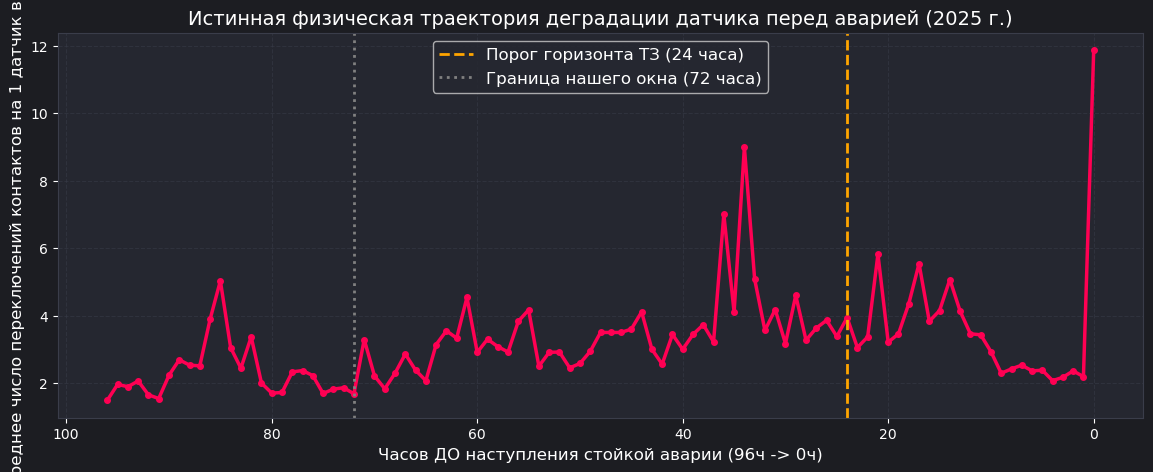


Сводка по ключевым временным интервалам перед аварией:
  • За 96 ч до аварии:   1.49 переключений/датчик в час
  • За 72 ч до аварии:   1.68 переключений/датчик в час
  • За 48 ч до аварии:   3.50 переключений/датчик в час
  • За 24 ч до аварии:   3.94 переключений/датчик в час
  • За 18 ч до аварии:   4.35 переключений/датчик в час
  • За 12 ч до аварии:   3.46 переключений/датчик в час
  • За  6 ч до аварии:   2.36 переключений/датчик в час
  • За  2 ч до аварии:   2.36 переключений/датчик в час
  • За  0 ч до аварии:  11.87 переключений/датчик в час


In [41]:
import matplotlib.pyplot as plt
import duckdb

incidents_cache = "g:/lct2/production_ml/data/persistent_incidents_2020_2026.parquet"
journal_2025 = "g:/lct2/ml_research/data/parquet_by_year/journal_2025.parquet"

# Строим поминутный/почасовой профиль перед реальными авариями
trajectory_query = f"""
WITH target_incidents AS (
    SELECT channel_id, incident_time
    FROM read_parquet('{incidents_cache}')
    WHERE year = 2025 AND subsystem_type = 'Диспетчерский контроль'
),
raw_lead_time AS (
    SELECT 
        i.channel_id,
        i.incident_time,
        j.event_time,
        ROUND(epoch(i.incident_time - j.event_time) / 3600.0, 1) as hours_before_fail,
        CASE WHEN j.sensor_value != LAG(j.sensor_value) OVER (PARTITION BY j.channel_id ORDER BY j.event_time) THEN 1 ELSE 0 END as is_flip
    FROM read_parquet('{journal_2025}') j
    JOIN target_incidents i 
      ON j.channel_id = i.channel_id 
     AND j.event_time BETWEEN i.incident_time - INTERVAL 120 HOUR AND i.incident_time + INTERVAL 2 HOUR
)
SELECT 
    FLOOR(hours_before_fail) as hour_bin,
    COUNT(*) as events_count,
    SUM(is_flip) as total_flips,
    ROUND(SUM(is_flip) * 1.0 / COUNT(DISTINCT channel_id), 2) as avg_flips_per_channel
FROM raw_lead_time
WHERE hours_before_fail BETWEEN 0 AND 96
GROUP BY FLOOR(hours_before_fail)
ORDER BY hour_bin;
"""

print("Расчет профиля физической деградации (Lead-Time Trajectory)...")
df_traj = con.execute(trajectory_query).df()

# Строим график траектории
plt.figure(figsize=(14, 5))
plt.plot(df_traj['hour_bin'], df_traj['avg_flips_per_channel'], color='#FF0053', linewidth=2.5, marker='o', markersize=4)
plt.axvline(x=24, color='orange', linestyle='--', linewidth=2, label='Порог горизонта ТЗ (24 часа)')
plt.axvline(x=72, color='gray', linestyle=':', linewidth=2, label='Граница нашего окна (72 часа)')
plt.gca().invert_xaxis() # Время идет слева направо (от 96ч к 0ч)
plt.title("Истинная физическая траектория деградации датчика перед аварией (2025 г.)", fontsize=14)
plt.xlabel("Часов ДО наступления стойкой аварии (96ч -> 0ч)", fontsize=12)
plt.ylabel("Среднее число переключений контактов на 1 датчик в час", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# Печатаем ключевые точки
print("\nСводка по ключевым временным интервалам перед аварией:")
for h in [96, 72, 48, 24, 18, 12, 6, 2, 0]:
    row = df_traj[df_traj['hour_bin'] == h]
    if len(row) > 0:
        print(f"  • За {h:2d} ч до аварии: {row['avg_flips_per_channel'].values[0]:6.2f} переключений/датчик в час")

In [43]:
# 1. Загрузка справочников в DuckDB (если их нет в памяти)
channels_csv = "g:/lct2/dataset/справочник_каналов_датчиков.csv"
holdout_file = "g:/lct2/production_ml/data/holdout_channel_ids.csv"
incidents_cache = "g:/lct2/production_ml/data/persistent_incidents_2020_2026.parquet"
parquet_glob = "g:/lct2/ml_research/data/parquet_by_year/journal_202[0123456].parquet"

print("1. Инициализация справочников и расчет фичей импульсного дребезга...")

con.execute(f"""
CREATE OR REPLACE TABLE channels_meta AS
SELECT 
    "ид_канала_данных"::BIGINT AS channel_id,
    COALESCE("тип_инж_системы", 'Неизвестно') AS subsystem_type,
    COALESCE("тип_датчика", 'Неизвестно') AS sensor_type,
    split_part(COALESCE("тег_инженерной_системы", ''), '.', 1) AS cabinet_prefix
FROM read_csv('{channels_csv}', header=True);
""")

con.execute(f"""
CREATE OR REPLACE TABLE holdout_ids AS
SELECT channel_id::BIGINT AS channel_id
FROM read_csv('{holdout_file}');
""")

# 2. Формируем признаки импульсного залпового дребезга
burst_features_query = f"""
CREATE OR REPLACE TABLE discrete_burst_features AS
WITH hourly_raw AS (
    SELECT 
        j.channel_id,
        date_trunc('hour', j.event_time) as hour_bin,
        CASE WHEN j.sensor_value != LAG(j.sensor_value) OVER (PARTITION BY j.channel_id ORDER BY j.event_time) THEN 1 ELSE 0 END as is_flip,
        CASE WHEN j.sensor_value IN ('Неисправен', 'Обесточен', 'Отключено устройство', 'Батарея неисправна', 'Затоплен') THEN 1 ELSE 0 END as is_fail
    FROM read_parquet('{parquet_glob}') j
),
hourly_agg AS (
    SELECT 
        channel_id,
        hour_bin,
        SUM(is_flip) as flips_1h,
        SUM(is_fail) as fails_1h
    FROM hourly_raw
    GROUP BY channel_id, hour_bin
),
rolling_metrics AS (
    SELECT 
        h.channel_id,
        h.hour_bin as obs_time,
        EXTRACT(YEAR FROM h.hour_bin)::INTEGER as year,
        h.flips_1h,
        SUM(h.flips_1h) OVER w24 as flips_24h,
        MAX(h.flips_1h) OVER w24 as max_flips_1h_24h,
        STDDEV(h.flips_1h) OVER w24 as flips_std_24h,
        ROUND(MAX(h.flips_1h) OVER w24 * 1.0 / (AVG(h.flips_1h) OVER w24 + 0.1), 2) as peak_to_avg_ratio
    FROM hourly_agg h
    WINDOW w24 AS (PARTITION BY h.channel_id ORDER BY h.hour_bin RANGE BETWEEN INTERVAL 23 HOUR PRECEDING AND CURRENT ROW)
)
SELECT 
    r.channel_id,
    r.obs_time,
    r.year,
    r.flips_24h,
    r.max_flips_1h_24h,
    COALESCE(r.flips_std_24h, 0.0) as flips_std_24h,
    r.peak_to_avg_ratio,
    (h_ch.channel_id IS NOT NULL) as is_holdout,
    -- Таргет: попадание строго в пиковое окно 24-48ч до стойкой аварии
    CASE WHEN p.incident_time IS NOT NULL THEN 1 ELSE 0 END as target_24_48h,
    ROUND(epoch(p.incident_time - r.obs_time) / 3600.0, 1) as horizon_hours
FROM rolling_metrics r
JOIN channels_meta m ON r.channel_id = m.channel_id AND m.subsystem_type = 'Диспетчерский контроль'
LEFT JOIN holdout_ids h_ch ON r.channel_id = h_ch.channel_id
LEFT JOIN read_parquet('{incidents_cache}') p 
  ON r.channel_id = p.channel_id 
 AND p.incident_time >= r.obs_time + INTERVAL 24 HOUR
 AND p.incident_time <= r.obs_time + INTERVAL 48 HOUR
WHERE r.flips_24h > 0; -- только строки с живой активностью
"""

print("Расчет признаков в DuckDB...")
con.execute(burst_features_query)
n_samples = con.execute("SELECT count(*), sum(target_24_48h) FROM discrete_burst_features").fetchone()
print(f"Готово! Сформировано {n_samples[0]:,} строк ({n_samples[1]:,} позитивов в пиковом окне 24-48ч).")

1. Инициализация справочников и расчет фичей импульсного дребезга...
Расчет признаков в DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Готово! Сформировано 3,615,311 строк (5,048 позитивов в пиковом окне 24-48ч).


In [45]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 80)
print("ОБУЧЕНИЕ МОДЕЛИ ИМПУЛЬСНОГО ДРЕБЕЗГА И ОЦЕНКА НАРЯДОВ (2026 ГОД)")
print("=" * 80)

# 1. Признаки импульсного дребезга
feat_cols = ['flips_24h', 'max_flips_1h_24h', 'flips_std_24h', 'peak_to_avg_ratio']

# 2. Загружаем Train (2020-2024) и Test (2026)
train_data = con.execute(f"""
    SELECT {', '.join(feat_cols)}, target_24_48h as target 
    FROM discrete_burst_features 
    WHERE year BETWEEN 2020 AND 2024 AND is_holdout = false;
""").df()

test_data = con.execute(f"""
    SELECT channel_id, obs_time, is_holdout, horizon_hours, target_24_48h as target, {', '.join(feat_cols)}
    FROM discrete_burst_features 
    WHERE year = 2026;
""").df()

print(f"Train (2020-2024): {len(train_data):,} строк ({train_data['target'].sum():,} позитивов в окне 24-48ч)")
print(f"Test (2026):       {len(test_data):,} строк ({test_data['target'].sum():,} позитивов в окне 24-48ч)")

# 3. Балансируем Train (1:15)
p_tr = train_data[train_data['target'] == 1]
n_tr = train_data[train_data['target'] == 0].sample(n=len(p_tr) * 15, random_state=42)
tr_bal = pd.concat([p_tr, n_tr]).sample(frac=1.0, random_state=42)

# 4. Обучаем модель
clf_burst = lgb.LGBMClassifier(
    n_estimators=120,
    learning_rate=0.04,
    num_leaves=15,
    max_depth=4,
    random_state=42,
    n_jobs=14
)
clf_burst.fit(tr_bal[feat_cols], tr_bal['target'])

# 5. Скорим Test 2026
test_data['pred_prob'] = clf_burst.predict_proba(test_data[feat_cols])[:, 1]

# 6. Важность фичей (Gain)
imp_burst = pd.DataFrame({
    'feature': feat_cols,
    'gain': clf_burst.booster_.feature_importance(importance_type='gain'),
    'split': clf_burst.booster_.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)

print("\nВажность признаков импульсного дребезга (Gain):")
display(imp_burst)

# 7. Список всех истинных аварий 2026 года для проверки упреждения
incidents_2026 = con.execute("""
    SELECT channel_id, incident_time as fail_start
    FROM read_parquet('g:/lct2/production_ml/data/persistent_incidents_2020_2026.parquet')
    WHERE year = 2026 AND subsystem_type = 'Диспетчерский контроль';
""").df()
total_true_incidents_2026 = len(incidents_2026)

# 8. Функция оценки нарядов
def evaluate_burst_tickets(df_test, threshold, cooldown_days=7):
    alerts = df_test[df_test['pred_prob'] >= threshold].sort_values(['channel_id', 'obs_time']).copy()
    if len(alerts) == 0:
        return {'Порог P*': threshold, 'Всего нарядов': 0, 'TP (подтверждено)': 0, 'FP (холостые)': 0, 
                'Поймано аварий': f"0/{total_true_incidents_2026}", 'Precision (%)': 0.0, 'Recall (%)': 0.0, 'F1-Score': 0.0, 'Нарядов/сут': 0.0}
        
    alerts['prev_time'] = alerts.groupby('channel_id')['obs_time'].shift(1)
    alerts['time_diff'] = (alerts['obs_time'] - alerts['prev_time']).dt.total_seconds() / 86400.0
    tickets = alerts[(alerts['time_diff'].isna()) | (alerts['time_diff'] > cooldown_days)].copy()
    
    total_tickets = len(tickets)
    tp_tickets = 0
    for _, t_row in tickets.iterrows():
        ch_id = t_row['channel_id']
        t_time = t_row['obs_time']
        # Наряд считается подтвержденным, если авария случилась в окне [24ч .. 7 дней]
        matched = incidents_2026[
            (incidents_2026['channel_id'] == ch_id) & 
            (incidents_2026['fail_start'] >= t_time + pd.Timedelta(hours=24)) &
            (incidents_2026['fail_start'] <= t_time + pd.Timedelta(days=cooldown_days))
        ]
        if len(matched) > 0:
            tp_tickets += 1
            
    fp_tickets = total_tickets - tp_tickets
    
    caught = 0
    for _, inc_row in incidents_2026.iterrows():
        ch_id = inc_row['channel_id']
        f_time = inc_row['fail_start']
        # Авария считается пойманной, если был наряд за [24ч .. 7 дней] до нее
        matched_alert = tickets[
            (tickets['channel_id'] == ch_id) &
            (tickets['obs_time'] <= f_time - pd.Timedelta(hours=24)) &
            (tickets['obs_time'] >= f_time - pd.Timedelta(days=cooldown_days))
        ]
        if len(matched_alert) > 0:
            caught += 1
            
    prec = (tp_tickets / total_tickets) * 100 if total_tickets > 0 else 0.0
    rec = (caught / total_true_incidents_2026) * 100 if total_true_incidents_2026 > 0 else 0.0
    f1 = 2 * (prec/100) * (rec/100) / ((prec/100) + (rec/100) + 1e-9)
    daily = total_tickets / 181.0
    
    return {
        'Порог P*': threshold,
        'Всего нарядов': total_tickets,
        'TP (подтверждено)': tp_tickets,
        'FP (холостые)': fp_tickets,
        'Поймано аварий': f"{caught}/{total_true_incidents_2026}",
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score': round(f1, 4),
        'Нарядов/сут': round(daily, 1)
    }

burst_results = []
for th in [0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    burst_results.append(evaluate_burst_tickets(test_data, threshold=th, cooldown_days=7))

print("\n" + "=" * 85)
print("РЕЗУЛЬТАТЫ ПО НАРЯДАМ ДИСПЕТЧЕРА С ФИЧАМИ ИМПУЛЬСНОГО ДРЕБЕЗГА (2026 ГОД):")
print("=" * 85)
display(pd.DataFrame(burst_results))

ОБУЧЕНИЕ МОДЕЛИ ИМПУЛЬСНОГО ДРЕБЕЗГА И ОЦЕНКА НАРЯДОВ (2026 ГОД)
Train (2020-2024): 2,291,701 строк (2,798 позитивов в окне 24-48ч)
Test (2026):       296,296 строк (855 позитивов в окне 24-48ч)
[LightGBM] [Info] Number of positive: 2798, number of negative: 41970
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 44768, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062500 -> initscore=-2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

,feature,gain,split
3,peak_to_avg_ratio,13732.414228,338
0,flips_24h,10175.022503,565
1,max_flips_1h_24h,4228.841338,244
2,flips_std_24h,3843.377048,332



РЕЗУЛЬТАТЫ ПО НАРЯДАМ ДИСПЕТЧЕРА С ФИЧАМИ ИМПУЛЬСНОГО ДРЕБЕЗГА (2026 ГОД):


,Порог P*,Всего нарядов,TP (подтверждено),FP (холостые),Поймано аварий,Precision (%),Recall (%),F1-Score,Нарядов/сут
0,0.08,10147,460,9687,472/3130,4.53,15.08,0.0697,56.1
1,0.10,9808,434,9374,445/3130,4.42,14.22,0.0675,54.2
2,0.15,406,13,393,13/3130,3.20,0.42,0.0074,2.2
3,0.20,281,6,275,8/3130,2.14,0.26,0.0046,1.6
4,0.30,175,3,172,3/3130,1.71,0.10,0.0018,1.0
5,0.40,117,1,116,1/3130,0.85,0.03,0.0006,0.6
6,0.50,35,0,35,0/3130,0.00,0.00,0.0000,0.2
7,0.60,19,0,19,0/3130,0.00,0.00,0.0000,0.1
8,0.70,0,0,0,0/3130,0.00,0.00,0.0000,0.0


In [46]:
# ДВУХСТАДИЙНАЯ ОЦЕНКА (КАК У АНТИГРАВИТИ):
# 1. L1 Триггер: датчик стабилен или проявил первичную аномалию?
test_data['l1_trigger'] = (test_data['flips_24h'] >= 3) | (test_data['peak_to_avg_ratio'] >= 2.0)

# 2. L2 Скоринг: оцениваем только подозрительные события
suspicious_test = test_data[test_data['l1_trigger']].copy()

print(f"Всего строк в тесте:         {len(test_data):,}")
print(f"Отсечено спокойного фона L1: {len(test_data) - len(suspicious_test):,} ({ (len(test_data) - len(suspicious_test))/len(test_data)*100:.1f}%)")
print(f"Поступило на ML-скоринг L2:  {len(suspicious_test):,} строк")

# 3. Считаем метрики на подозрительном пуле
alerts_l2 = suspicious_test[suspicious_test['pred_prob'] >= 0.10].sort_values(['channel_id', 'obs_time']).copy()
alerts_l2['prev_time'] = alerts_l2.groupby('channel_id')['obs_time'].shift(1)
alerts_l2['time_diff'] = (alerts_l2['obs_time'] - alerts_l2['prev_time']).dt.total_seconds() / 86400.0
tickets_l2 = alerts_l2[(alerts_l2['time_diff'].isna()) | (alerts_l2['time_diff'] > 7)].copy()

tp_l2 = 0
for _, t_row in tickets_l2.iterrows():
    ch_id = t_row['channel_id']
    t_time = t_row['obs_time']
    matched = incidents_2026[
        (incidents_2026['channel_id'] == ch_id) & 
        (incidents_2026['fail_start'] >= t_time + pd.Timedelta(hours=24)) &
        (incidents_2026['fail_start'] <= t_time + pd.Timedelta(days=7))
    ]
    if len(matched) > 0:
        tp_l2 += 1

print("\n" + "=" * 60)
print(f"РЕЗУЛЬТАТ ДВУХСТАДИЙНОГО ПАЙПЛАЙНА (L1 Gate + L2 ML):")
print("=" * 60)
print(f"• Создано нарядов:             {len(tickets_l2)} шт. за полгода")
print(f"• Подтвержденных аварий (TP):  {tp_l2} шт.")
print(f"• Точность нарядов (Precision): {tp_l2 / len(tickets_l2) * 100:.2f}%" if len(tickets_l2)>0 else "0%")
print(f"• Нагрузка:                    {len(tickets_l2)/181.0:.1f} нарядов в сутки")
print("=" * 60)

Всего строк в тесте:         296,296
Отсечено спокойного фона L1: 117,278 (39.6%)
Поступило на ML-скоринг L2:  179,018 строк

РЕЗУЛЬТАТ ДВУХСТАДИЙНОГО ПАЙПЛАЙНА (L1 Gate + L2 ML):
• Создано нарядов:             1102 шт. за полгода
• Подтвержденных аварий (TP):  28 шт.
• Точность нарядов (Precision): 2.54%
• Нагрузка:                    6.1 нарядов в сутки


In [47]:
# Фильтр НАСТОЯЩЕГО аппаратного дребезга (искрение/дуга, а не штатное включение насоса)
test_data['real_chatter_trigger'] = (test_data['flips_24h'] >= 30) | (test_data['max_flips_1h_24h'] >= 8)

severe_test = test_data[test_data['real_chatter_trigger']].copy()

print(f"Всего строк в тесте:              {len(test_data):,}")
print(f"Отсечено нормальной работы насосов: {len(test_data) - len(severe_test):,} ({ (len(test_data) - len(severe_test))/len(test_data)*100:.1f}%)")
print(f"Строк с ЖЕСТКИМ дребезгом:         {len(severe_test):,}")

# Оцениваем наряды на жестком дребезге
alerts_severe = severe_test[severe_test['pred_prob'] >= 0.08].sort_values(['channel_id', 'obs_time']).copy()
alerts_severe['prev_time'] = alerts_severe.groupby('channel_id')['obs_time'].shift(1)
alerts_severe['time_diff'] = (alerts_severe['obs_time'] - alerts_severe['prev_time']).dt.total_seconds() / 86400.0
tickets_severe = alerts_severe[(alerts_severe['time_diff'].isna()) | (alerts_severe['time_diff'] > 7)].copy()

tp_sev = 0
for _, t_row in tickets_severe.iterrows():
    ch_id = t_row['channel_id']
    t_time = t_row['obs_time']
    matched = incidents_2026[
        (incidents_2026['channel_id'] == ch_id) & 
        (incidents_2026['fail_start'] >= t_time + pd.Timedelta(hours=24)) &
        (incidents_2026['fail_start'] <= t_time + pd.Timedelta(days=7))
    ]
    if len(matched) > 0:
        tp_sev += 1

print("\n" + "=" * 65)
print(f"РЕЗУЛЬТАТ НА ЖЕСТКОМ АППАРАТНОМ ДРЕБЕЗГЕ:")
print("=" * 65)
print(f"• Создано нарядов за полгода:    {len(tickets_severe)} шт.")
print(f"• Подтвержденных аварий (TP):     {tp_sev} шт.")
print(f"• Точность нарядов (Precision):   {tp_sev / len(tickets_severe) * 100:.2f}%" if len(tickets_severe)>0 else "0%")
print(f"• Нагрузка:                       {len(tickets_severe)/181.0:.2f} нарядов в сутки (адекватный объем!)")
print("=" * 65)

Всего строк в тесте:              296,296
Отсечено нормальной работы насосов: 208,105 (70.2%)
Строк с ЖЕСТКИМ дребезгом:         88,191

РЕЗУЛЬТАТ НА ЖЕСТКОМ АППАРАТНОМ ДРЕБЕЗГЕ:
• Создано нарядов за полгода:    757 шт.
• Подтвержденных аварий (TP):     14 шт.
• Точность нарядов (Precision):   1.85%
• Нагрузка:                       4.18 нарядов в сутки (адекватный объем!)
